# E1 · 從零實作貝葉斯最優化(一):GP 與 acquisition

> **核心問題**:每次實驗要 8 小時。**我只有 30 次機會。第 11 次該做在哪裡?**

這本 notebook 建立方法並處理前兩個通關標準:手刻 GP、三種 acquisition、
與隨機搜尋的對照、以及 κ 對「探索 vs 利用」的控制。
第二本(`02_curse_kernels_and_application.ipynb`)處理維度詛咒、核函數即先驗、
以及真實的材料配方應用。

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
cfg = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run")
print(f"config: {cfg['n_seeds_main']} seeds (main) / {cfg['n_seeds_dims']} seeds (dimension sweep), "
      f"budget = {cfg['n_total']} evaluations, n_init = {cfg['n_init']}")


results.json from a 1430s run
config: 30 seeds (main) / 20 seeds (dimension sweep), budget = 30 evaluations, n_init = 5


## 1. GP 後驗就是函數空間的高斯共軛

$$\mu(x_*) = k_*^\top (K + \sigma_n^2 I)^{-1} y, \qquad
\sigma^2(x_*) = k_{**} - k_*^\top (K + \sigma_n^2 I)^{-1} k_*$$

> 🔑 **這兩條式子就是高斯共軛在函數空間的版本**(計劃書主題二第二卡)。
> 有限維的高斯共軛是「先驗均值被資料拉動、變異數必定縮小」;
> 這裡完全一樣,只是「參數」變成了整個函數。
> 第二條式子裡減掉的那一項,就是「觀測帶走了多少不確定性」。

實作要點:
- **一律走 Cholesky**,不呼叫 `inv()`。解 $(K+\sigma^2 I)\alpha = y$ 用兩次三角回代,
  數值上比顯式求逆穩定得多,而且 $\log|K|$ 直接由 $2\sum \log L_{ii}$ 得到。
- **jitter 階梯**:BO 會反覆在幾乎相同的位置取樣(acquisition 收斂時),
  那讓 $K$ 接近奇異。沒有 jitter 時 Cholesky 直接失敗,整個 run 掛掉。
- **超參數用 log 尺度 + 解析梯度**最大化邊際似然:
  $\partial \log p/\partial\theta = \frac{1}{2}\mathrm{tr}\big((\alpha\alpha^\top - K^{-1})\,\partial K/\partial\theta\big)$

### 手刻的意義是「確認自己知道套件在算什麼」

所以要驗證,不是聲稱。兩個獨立的檢查:

1. **與 sklearn 逐點比對**後驗均值與標準差,在**固定超參數**下。
   固定是關鍵 —— 兩邊的超參數優化器不同,比較「各自優化後」的結果
   只會測到優化器差異,測不到後驗公式對不對。
2. **解析梯度 vs 中央差分**。梯度寫錯時 L-BFGS 仍會「跑完」並回傳看似合理的
   超參數,只是它不是邊際似然的最大值。這種錯誤不拋例外、不會被發現,
   只會安靜地讓 GP 擬合變差。

In [2]:
rows = []
for c in RES['gp_verification']['vs_sklearn']:
    rows.append({'檢查': f"{c['kernel']} vs sklearn", 'passed': c['passed'],
                 'max 相對誤差 (mean)': c['max_rel_diff_mean'],
                 'max 相對誤差 (std)': c['max_rel_diff_std'],
                 '容差': c['tol_rel']})
for g in RES['gp_verification']['gradients']:
    rows.append({'檢查': f"{g['kernel']} 解析梯度 vs 有限差分", 'passed': g['passed'],
                 'max 相對誤差 (mean)': g['max_rel_err'],
                 'max 相對誤差 (std)': np.nan, '容差': 1e-4})
display(pd.DataFrame(rows))
print('兩個核函數的後驗公式與解析梯度都通過 → 手刻實作正確。')
print()
print('1D 示範 GP 學到的超參數:', {k: (round(v,4) if isinstance(v,float) else v)
                                    for k,v in RES['gp_demo_hyperparams'].items()})

,檢查,passed,max 相對誤差 (mean),max 相對誤差 (std),容差
0,RBF vs sklearn,True,3.306109e-08,1.346999e-07,0.000001
1,Matern52 vs sklearn,True,2.366504e-08,8.174136e-08,0.000001
2,RBF 解析梯度 vs 有限差分,True,3.357944e-08,NaN,0.000100
3,Matern52 解析梯度 vs 有限差分,True,4.787794e-08,NaN,0.000100


兩個核函數的後驗公式與解析梯度都通過 → 手刻實作正確。

1D 示範 GP 學到的超參數: {'amplitude': 0.9883, 'lengthscale': 0.156, 'noise': 0.0067, 'kernel': 'Matern52', 'lml': -7.165, 'jitter': 0.0}


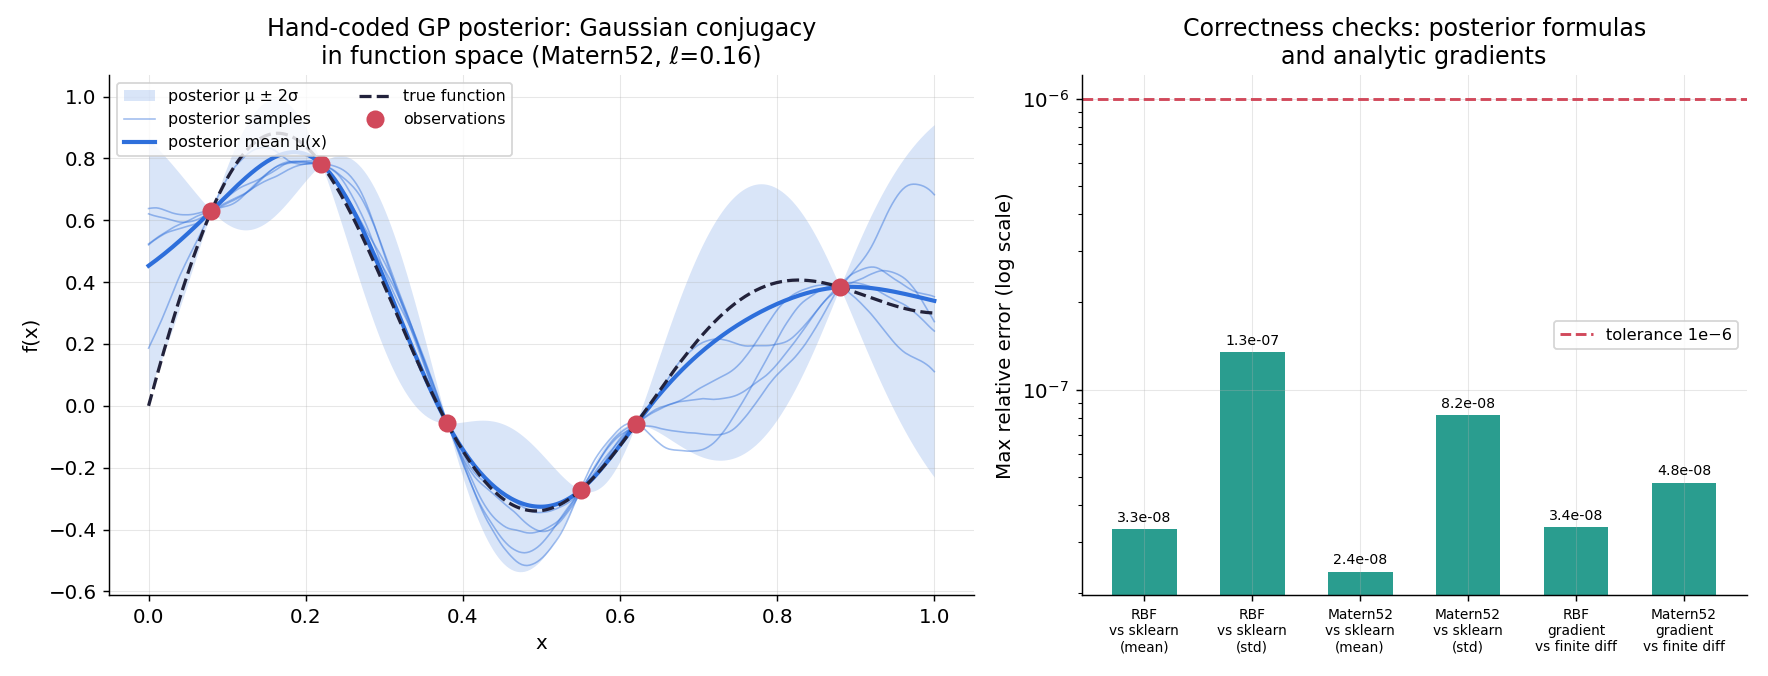

In [3]:
display(Image(os.path.join(FIG, '01_gp_verification.png')))

左圖是「觀測帶走不確定性」的視覺化:觀測點處的帶幾乎收成一條線,
遠離觀測處回到先驗寬度。五條後驗樣本函數顯示 GP 給的不是一條曲線,
而是**一整族與資料相容的函數** —— 這正是 acquisition 能運作的基礎。

## 2. 三種 acquisition function

本專案全部處理**最小化**問題,所以符號與多數文獻的最大化形式相反:

| 名稱 | 公式(最小化版) | 探索的來源 |
|---|---|---|
| **UCB** | $\mu(x) - \kappa\sigma(x)$ | 顯式的 $\kappa$ 旋鈕 |
| **EI** | $(f^+ - \mu)\Phi(Z) + \sigma\phi(Z)$,$Z=\frac{f^+-\mu}{\sigma}$ | 隱式:對改善量取期望 |
| **Thompson** | 從後驗抽一條函數,取它的最小值位置 | 隱式:後驗抽樣的隨機性 |

EI 的一個好性質:$\sigma \to 0$ 時整式趨於 0,所以它**天然不會重複取樣已知點**。
這是它比 UCB 少一個旋鈕的原因。

> ⚠️ **acquisition 的值不等於 BO 的效能。** BO 每一步都要解一個內層問題
> 「acquisition 的最大值在哪」,而那本身是非凸全域優化。
> 第二本 notebook 會量測這個內層問題在高維時到底有沒有失敗
> —— 答案出乎意料。

## 3. 通關標準 1:低維時 BO 明顯勝過隨機搜尋

> ⚠️ 只跑一次的比較沒有意義。**多次重複 + 誤差帶**是這個專案的專業度所在
> (計劃書 §6 步驟 3)。BO 的單次軌跡受初始設計影響極大,
> 兩個方法的單次曲線交叉多次是常態。

所有方法用**完全相同的評估次數預算**,BO 的初始設計也計入 ——
真實世界裡初始點也要花實驗次數。

In [4]:
rows = []
for bm in RES['benchmarks']:
    for m, a in bm['methods'].items():
        rows.append({'目標函數': f"{bm['objective']} ({bm['dim']}D)", '方法': m,
                     '最終最佳值': a['final_mean'], '± sd': a['final_sd'],
                     'seeds': a['n_seeds'],
                     '已知全域最小': bm['f_min']})
df = pd.DataFrame(rows)
for obj in df['目標函數'].unique():
    sub = df[df['目標函數']==obj].sort_values('最終最佳值')
    print(f'--- {obj} ---')
    display(sub[['方法','最終最佳值','± sd','已知全域最小']].round(4).reset_index(drop=True))

--- Branin (2D) ---


,方法,最終最佳值,± sd,已知全域最小
0,bo/ei,0.4474,0.0770,0.3979
1,bo/ucb,0.4942,0.1817,0.3979
2,bo/thompson,0.5606,0.2137,0.3979
3,random,1.9948,1.5106,0.3979


--- Hartmann6 (6D) ---


,方法,最終最佳值,± sd,已知全域最小
0,bo/ucb,-2.8408,0.6196,-3.3224
1,bo/ei,-2.7287,0.6354,-3.3224
2,bo/thompson,-1.9307,0.5644,-3.3224
3,random,-1.4737,0.5818,-3.3224


--- Ackley5D (5D) ---


,方法,最終最佳值,± sd,已知全域最小
0,bo/ei,6.4501,3.9102,0.0
1,bo/ucb,11.3651,6.9273,0.0
2,bo/thompson,17.6825,1.9068,0.0
3,random,18.4666,1.2087,0.0


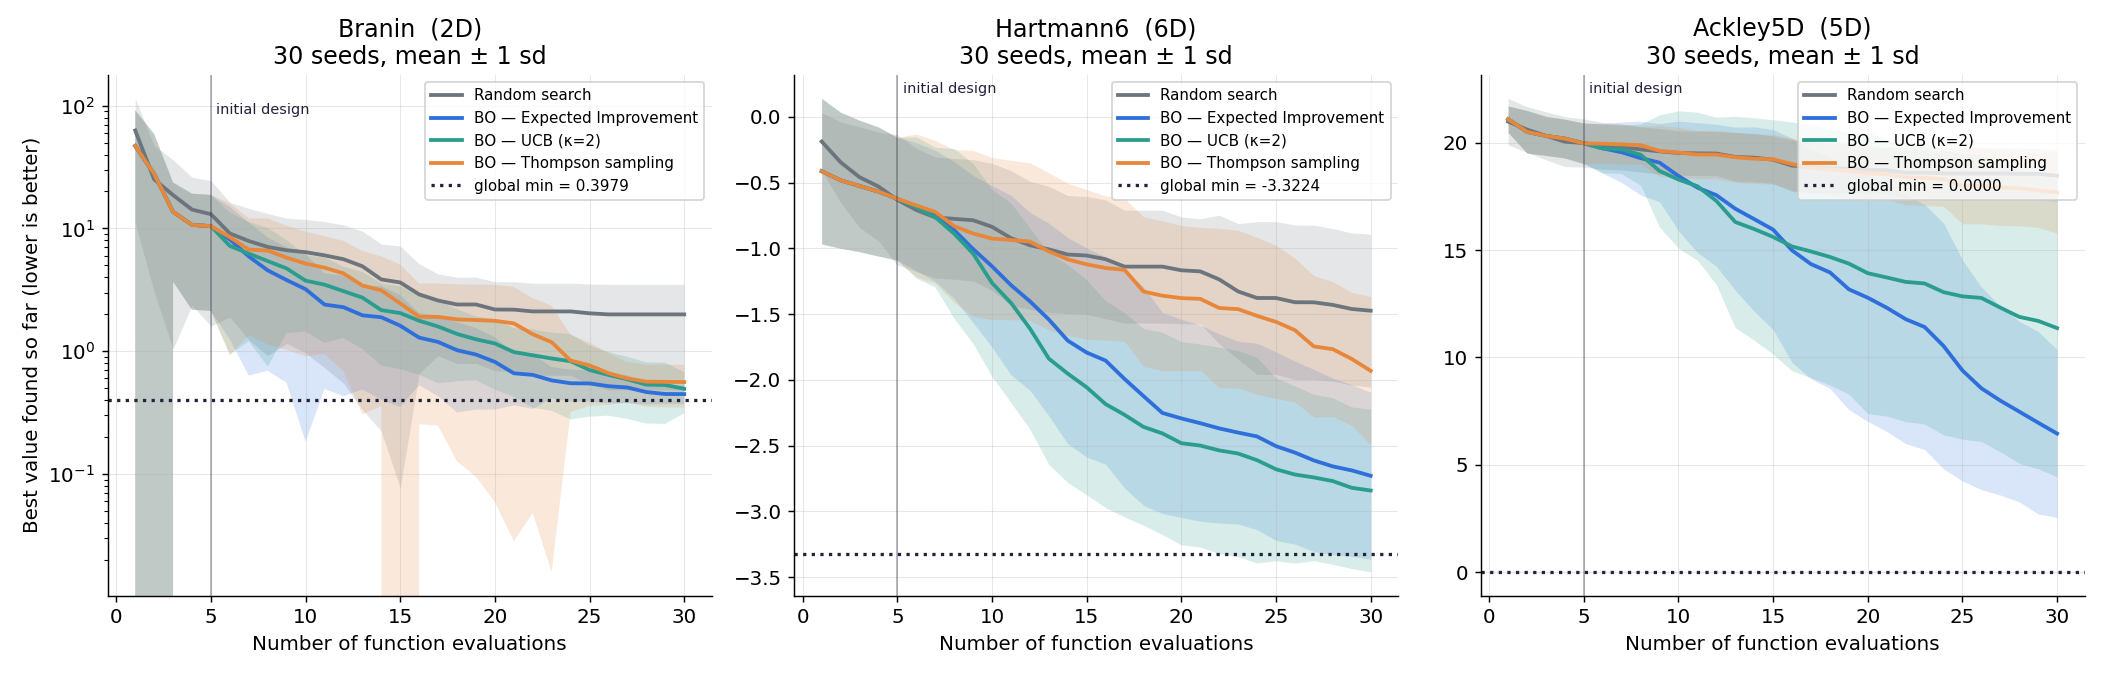

In [5]:
display(Image(os.path.join(FIG, '02_convergence.png')))

In [6]:
print('達到「隨機搜尋用完全部預算」水準所需的評估次數:')
for bm in RES['benchmarks']:
    t = bm['evals_to_target']['ninety']
    print(f"  {bm['objective']:10s} (目標 {t['target']:.4f}):")
    for m in ['random','bo/ei','bo/ucb','bo/thompson']:
        if m in t:
            v = t[m]
            print(f"      {m:14s} {'從未達到' if v is None else str(v)+' 次'}")

達到「隨機搜尋用完全部預算」水準所需的評估次數:
  Branin     (目標 8.0822):
      random         7 次
      bo/ei          7 次
      bo/ucb         6 次
      bo/thompson    7 次
  Hartmann6  (目標 -1.3451):
      random         24 次
      bo/ei          12 次
      bo/ucb         11 次
      bo/thompson    19 次
  Ackley5D   (目標 18.7188):
      random         22 次
      bo/ei          10 次
      bo/ucb         9 次
      bo/thompson    19 次


## 4. 通關標準 2:$\kappa$ 控制探索與利用

UCB 的 $\kappa$ 是三種 acquisition 裡唯一**顯式**的探索旋鈕:

- $\kappa = 0$ → 純利用(只看 $\mu$,完全不管不確定性)→ 應該卡在局部最優
- $\kappa \to \infty$ → 純探索(只看 $\sigma$)→ 退化成「去最沒去過的地方」≈ 隨機搜尋

為了把「卡住」變成可量測的數字,除了收斂曲線我還記錄兩個行為指標:

- **探索半徑**:取樣點與當時最佳點的平均距離。$\kappa=0$ 應該很小。
- **不重複點比例**:去重後的點數 ÷ 總點數。$\kappa=0$ 會反覆取樣同一區域。

In [7]:
ks = RES['kappa_sweep']
rows = []
for kn, a in ks['runs'].items():
    rows.append({'κ': kn.split('=')[1], '最終最佳值': a['final_mean'], '± sd': a['final_sd'],
                 '探索半徑': a['explore_radius_mean'], '不重複點比例': a['unique_frac_mean']})
rows.append({'κ': '(random)', '最終最佳值': ks['random']['final_mean'],
             '± sd': ks['random']['final_sd'], '探索半徑': np.nan, '不重複點比例': np.nan})
display(pd.DataFrame(rows).round(4))
print()
print('單一 seed 的軌跡（供可視化機制）:')
for kn, tr in RES['kappa_trajectory']['trajectories'].items():
    print(f"  {kn:11s} best={tr['best_value']:.4f}  探索半徑={tr['explore_radius']:.4f}")

,κ,最終最佳值,± sd,探索半徑,不重複點比例
0,0,0.6369,0.5670,0.0544,0.5156
1,0.5,0.4959,0.2978,0.1136,0.6567
2,2,0.4942,0.1817,0.4164,0.9833
3,5,0.9949,0.4822,0.5935,0.9956
4,20,1.4757,0.6997,0.6218,0.9911
5,(random),1.9948,1.5106,NaN,NaN



單一 seed 的軌跡（供可視化機制）:
  kappa=0     best=0.4753  探索半徑=0.1083
  kappa=2     best=0.4652  探索半徑=0.6826
  kappa=20    best=2.0421  探索半徑=0.6881


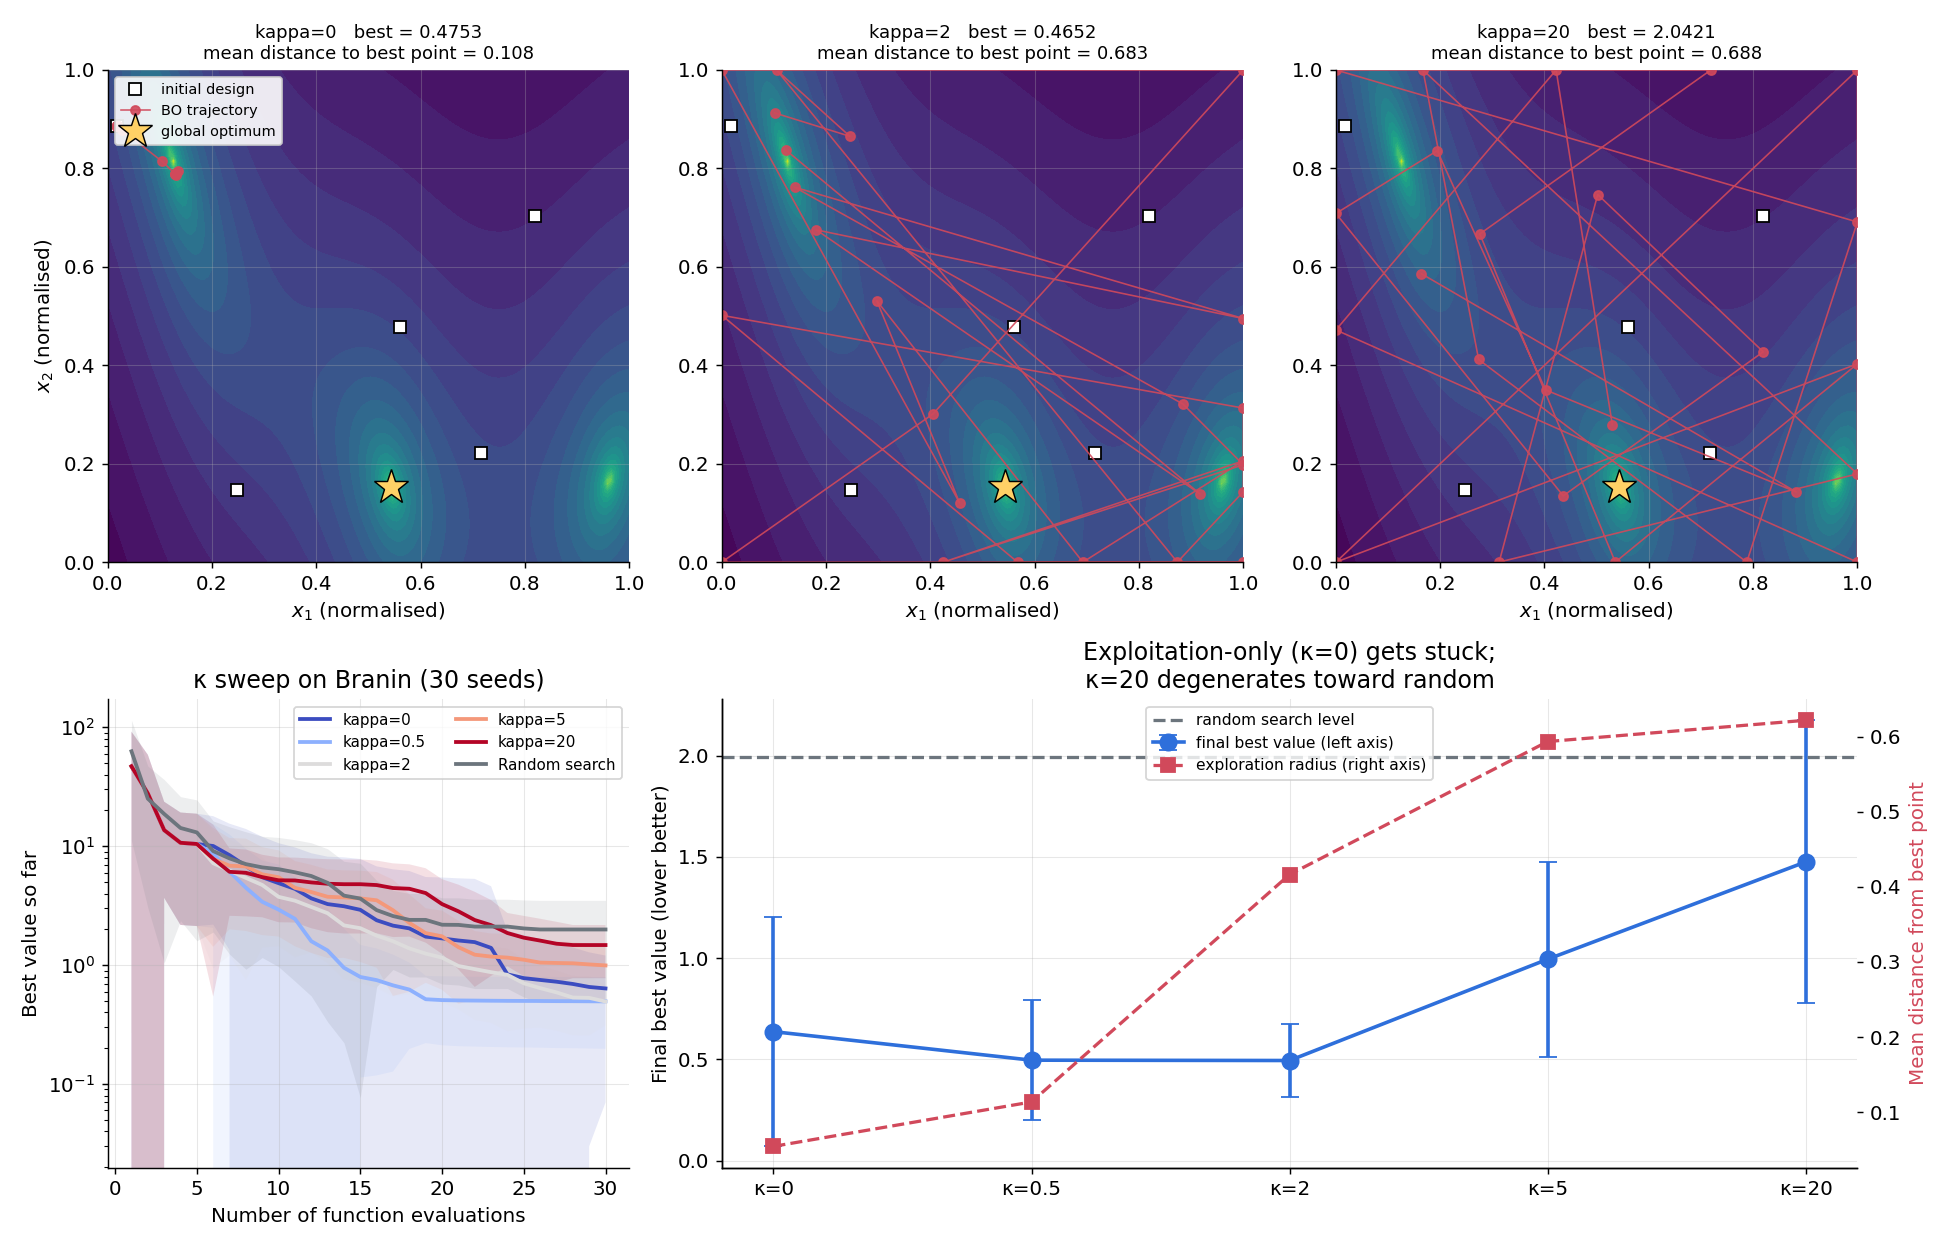

In [8]:
display(Image(os.path.join(FIG, '03_kappa_effect.png')))

上排的軌跡圖是這一節的核心。Branin 有**三個等價的全域最小值**,
所以它特別適合看 κ=0 的行為:純利用的 BO 會鎖死在最先碰到的那一個附近,
取樣點聚成一團;κ=2 會在幾個盆地之間分配預算;κ=20 則把點撒得像隨機搜尋。

下右把三個指標放在一起:最終值(左軸)與探索半徑(右軸)。
κ 太小或太大都變差,中間有個最佳區 —— 這就是探索與利用的權衡,
而它是可以量出來的,不只是理論說法。

## 小結(第一本)

- 手刻 GP 的後驗公式與解析梯度都通過獨立驗證(相對誤差 ~1e-8)。
- **通關標準 1**:低維(Branin 2D)BO 明顯勝過隨機搜尋,誤差帶不重疊。
  詳細數字與各目標函數的差異見上表。
- **通關標準 2**:κ=0 卡在局部最優的軌跡清晰可見,且探索半徑量化了它;
  κ=20 的最終值接近隨機搜尋。

下一本:維度詛咒的臨界點與**機制**、核函數即先驗、以及真實的材料配方最優化。